# 🍅 Tomato Leaf Disease Classifier
### ResNet50 · 10-Class Disease Detection · Binary Wrapper · ESP32-CAM Ready

---

**Two modes in one model:**
- 🔬 **Multi-class:** Identify the *specific disease* (9 diseases + healthy)
- ✅ **Binary:** Just tell you *healthy vs infected* (derived from multi-class output)

**Classes:**

| Index | Class | Type |
|---|---|---|
| 0 | Bacterial Spot | 🔴 Infected |
| 1 | Early Blight | 🔴 Infected |
| 2 | Late Blight | 🔴 Infected |
| 3 | Leaf Mold | 🔴 Infected |
| 4 | Septoria Leaf Spot | 🔴 Infected |
| 5 | Spider Mites | 🔴 Infected |
| 6 | Target Spot | 🔴 Infected |
| 7 | Yellow Leaf Curl Virus | 🔴 Infected |
| 8 | Mosaic Virus | 🔴 Infected |
| 9 | Healthy | 🟢 Healthy |

**Dataset structure (already split):**
```
tomato/
  train/  ← 10 class folders
  val/    ← 10 class folders  (used for both validation & final test)
```

> ⚡ Enable GPU: Notebook Settings → Accelerator → GPU T4 x2

## 1 · Setup & Imports

In [29]:
import os
import random
import warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.callbacks import (
    ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
)
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_curve, auc
)
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

gpus = tf.config.list_physical_devices('GPU')
print(f"TensorFlow : {tf.__version__}")
print(f"GPUs found : {len(gpus)}")
for g in gpus:
    print(f"  {g}")

if gpus:
    tf.keras.mixed_precision.set_global_policy('mixed_float16')
    print("Mixed precision : ON (float16)")
else:
    print("⚠️  No GPU — enable it in Notebook Settings for reasonable speed.")

TensorFlow : 2.19.0
GPUs found : 2
  PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
  PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')
Mixed precision : ON (float16)


## 2 · Configuration

In [30]:
# ── Paths ──
# Dataset is already split by Kaggle into train/ and val/
INPUT_DIR = Path('/kaggle/input/datasets/kaustubhb999/tomatoleaf/tomato')
TRAIN_DIR = INPUT_DIR / 'train'
VAL_DIR   = INPUT_DIR / 'val'
WORK_DIR  = Path('/kaggle/working')
MODEL_DIR = WORK_DIR / 'models'
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# ── Image ──
IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 10     # 9 diseases + 1 healthy

# ── Training ──
EPOCHS_PHASE1 = 15   # frozen base
EPOCHS_PHASE2 = 25   # fine-tune top layers
LR_PHASE1     = 1e-3
LR_PHASE2     = 1e-5
LABEL_SMOOTH  = 0.1
UNFREEZE_FROM = -30  # unfreeze last 30 layers of ResNet50 in phase 2

# ── Binary mapping ──
# After training, any class index != HEALTHY_IDX is considered infected.
# This is set automatically after we load the dataset (see section 3).
HEALTHY_FOLDER_NAME = 'Tomato___healthy'

print("Config loaded ✅")
print(f"  Train dir   : {TRAIN_DIR}")
print(f"  Val dir     : {VAL_DIR}")
print(f"  Num classes : {NUM_CLASSES}")
print(f"  Image size  : {IMG_SIZE}")
print(f"  Batch size  : {BATCH_SIZE}")

Config loaded ✅
  Train dir   : /kaggle/input/datasets/kaustubhb999/tomatoleaf/tomato/train
  Val dir     : /kaggle/input/datasets/kaustubhb999/tomatoleaf/tomato/val
  Num classes : 10
  Image size  : (224, 224)
  Batch size  : 32


## 3 · Explore Dataset

In [31]:
# ── Count images per class in train and val ──
train_folders = sorted([f for f in TRAIN_DIR.iterdir() if f.is_dir()])
val_folders   = sorted([f for f in VAL_DIR.iterdir()   if f.is_dir()])

print(f"{'Class':<42} {'Train':>7} {'Val':>7}")
print('─' * 58)

class_counts = {}
for tf_dir, vf_dir in zip(train_folders, val_folders):
    n_train = len(list(tf_dir.glob('*.*')))
    n_val   = len(list(vf_dir.glob('*.*')))
    tag = '🟢' if 'healthy' in tf_dir.name.lower() else '🔴'
    print(f"  {tag} {tf_dir.name:<40} {n_train:>7} {n_val:>7}")
    class_counts[tf_dir.name] = {'train': n_train, 'val': n_val}

total_train = sum(v['train'] for v in class_counts.values())
total_val   = sum(v['val']   for v in class_counts.values())
print('─' * 58)
print(f"  {'TOTAL':<42} {total_train:>7} {total_val:>7}")

Class                                        Train     Val
──────────────────────────────────────────────────────────
  🔴 Tomato___Bacterial_spot                     1000     100
  🔴 Tomato___Early_blight                       1000     100
  🔴 Tomato___Late_blight                        1000     100
  🔴 Tomato___Leaf_Mold                          1000     100
  🔴 Tomato___Septoria_leaf_spot                 1000     100
  🔴 Tomato___Spider_mites Two-spotted_spider_mite    1000     100
  🔴 Tomato___Target_Spot                        1000     100
  🔴 Tomato___Tomato_Yellow_Leaf_Curl_Virus      1000     100
  🔴 Tomato___Tomato_mosaic_virus                1000     100
  🟢 Tomato___healthy                            1000     100
──────────────────────────────────────────────────────────
  TOTAL                                        10000    1000


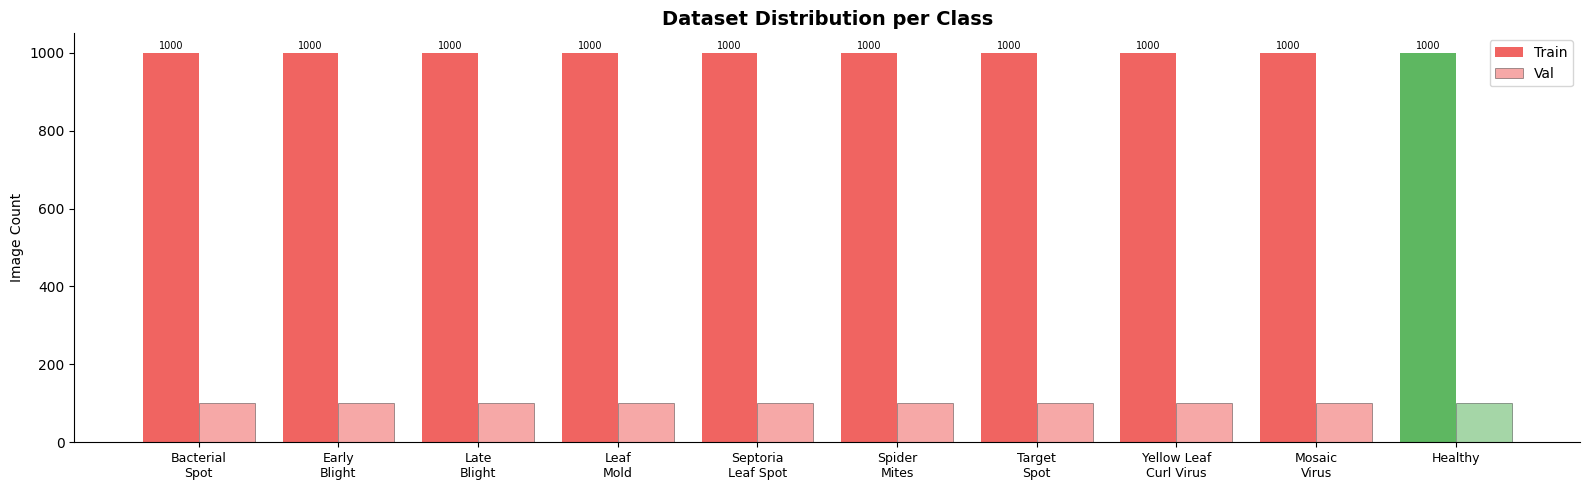

In [32]:
# ── Class distribution bar chart ──
short_names = [
    'Bacterial\nSpot', 'Early\nBlight', 'Late\nBlight', 'Leaf\nMold',
    'Septoria\nLeaf Spot', 'Spider\nMites', 'Target\nSpot',
    'Yellow Leaf\nCurl Virus', 'Mosaic\nVirus', 'Healthy'
]

train_counts = [v['train'] for v in class_counts.values()]
val_counts   = [v['val']   for v in class_counts.values()]

# Colour: green for healthy, red for diseases
bar_colors = ['#4CAF50' if 'healthy' in k.lower() else '#EF5350'
              for k in class_counts.keys()]

x = np.arange(NUM_CLASSES)
w = 0.4

fig, ax = plt.subplots(figsize=(16, 5))
b1 = ax.bar(x - w/2, train_counts, w, color=bar_colors, alpha=0.9, label='Train')
b2 = ax.bar(x + w/2, val_counts,   w, color=bar_colors, alpha=0.5, label='Val',
            edgecolor='black', linewidth=0.5)

ax.set_xticks(x)
ax.set_xticklabels(short_names, fontsize=9)
ax.set_ylabel('Image Count')
ax.set_title('Dataset Distribution per Class', fontsize=14, fontweight='bold')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)

for bar in b1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            str(int(bar.get_height())), ha='center', fontsize=7)

plt.tight_layout()
plt.savefig(WORK_DIR / 'dataset_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

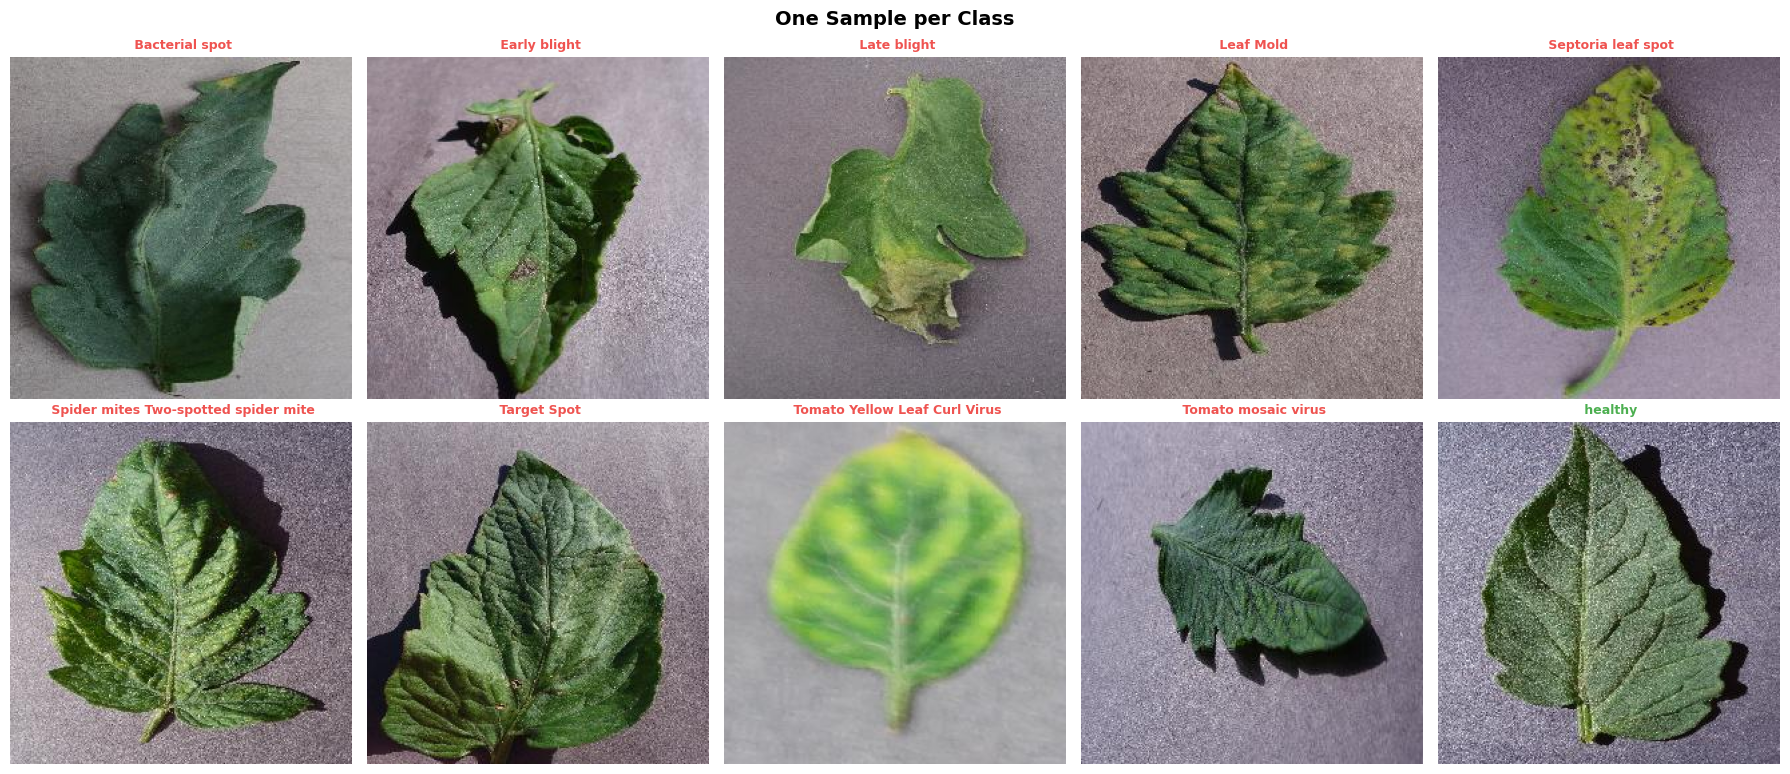

In [33]:
# ── Sample images: one per class ──
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
fig.suptitle('One Sample per Class', fontsize=14, fontweight='bold')

for ax, (folder, counts) in zip(axes.flatten(), class_counts.items()):
    folder_path = TRAIN_DIR / folder
    img_file = random.choice(list(folder_path.glob('*.*')))
    img = Image.open(img_file).convert('RGB')
    ax.imshow(img)
    ax.axis('off')
    is_healthy = 'healthy' in folder.lower()
    label = folder.replace('Tomato__', '').replace('_', ' ')
    color = '#4CAF50' if is_healthy else '#EF5350'
    ax.set_title(label, fontsize=9, color=color, fontweight='bold')
    for spine in ax.spines.values():
        spine.set_edgecolor(color); spine.set_linewidth(3); spine.set_visible(True)

plt.tight_layout()
plt.savefig(WORK_DIR / 'sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

## 4 · Augmentation Pipeline

Augmentation is defined here but **applied inside the model on the GPU** (not in the data pipeline).
This solves two problems at once:

| Problem | Old approach | New approach |
|---|---|---|
| **Black images** | `GaussianNoise` + `RandomBrightness` on float16 → zeros | Removed noise; explicit float32 range on brightness |
| **CPU bottleneck** | `aug()` ran in `.map()` on CPU | Aug layer is first layer of model → runs on GPU |

Augmentation is **automatically disabled** during `model.evaluate()` and `model.predict()` — no code changes needed for inference.

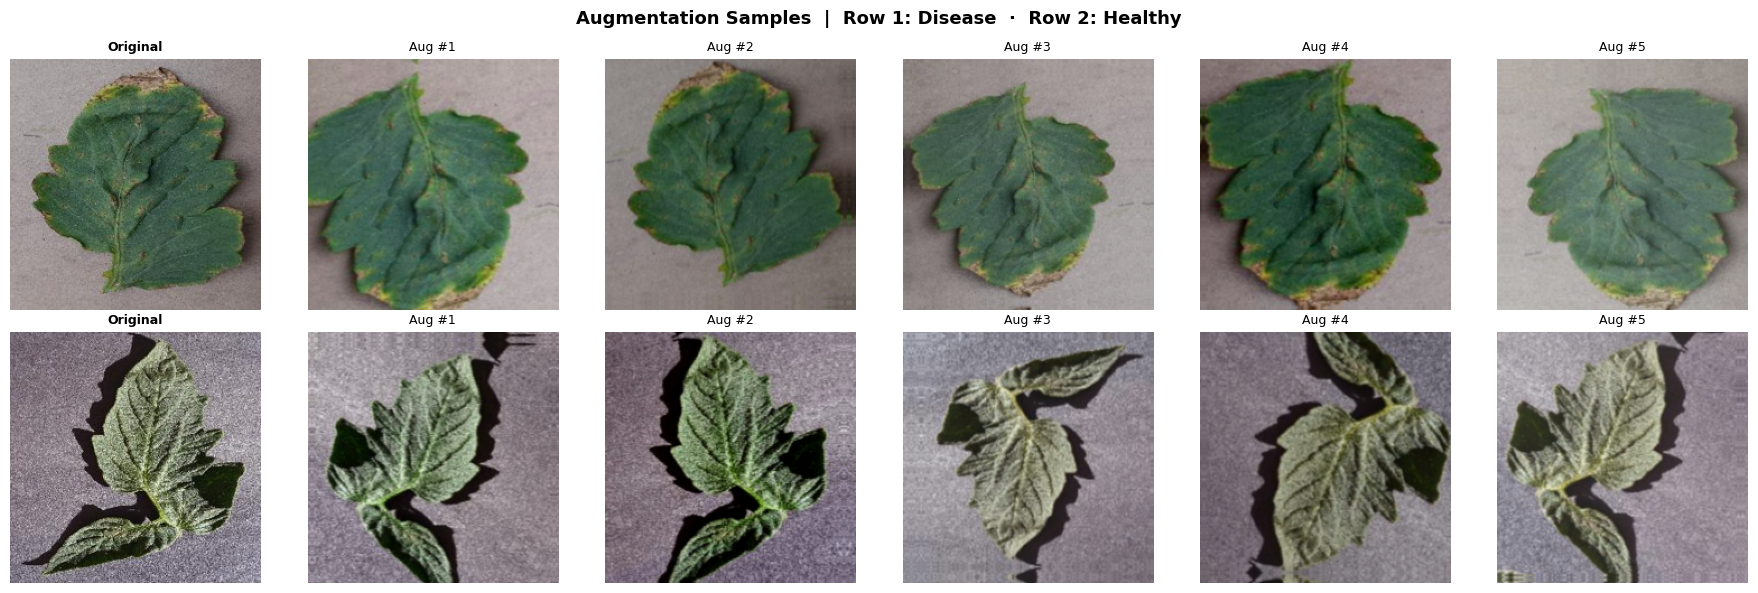

Augmentation pipeline ready ✅


In [34]:
# Replace ALL Keras augmentation layers with tf.image ops.
# Keras RandomBrightness is the root cause of black images — it has
# unpredictable dtype behaviour internally. tf.image functions operate
# on explicit float32 tensors and clip safely.
@tf.keras.utils.register_keras_serializable()
class TFImageAugmentation(keras.layers.Layer):
    """
    Custom augmentation layer using tf.image ops.
    - Runs on GPU (it's a Keras layer inside the model)
    - Automatically disabled during model.predict / model.evaluate
    - All ops work on float32 in [0, 1] range — no black image risk
    """
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def call(self, x, training=False):
        if not training:
            return x

        # Cast to float32 for all tf.image ops
        x = tf.cast(x, tf.float32)

        # Horizontal + vertical flip
        x = tf.image.random_flip_left_right(x)
        x = tf.image.random_flip_up_down(x)

        # Brightness: max_delta=0.1 means ±10% of [0,1] range
        # tf.image clips the result to [0,1] automatically
        x = tf.image.random_brightness(x, max_delta=0.1)

        # Contrast: factor sampled from [1-0.15, 1+0.15] = [0.85, 1.15]
        # tf.image clips to [0,1] automatically
        x = tf.image.random_contrast(x, lower=0.85, upper=1.15)

        # Hue shift: simulates different lighting colour temperatures
        x = tf.image.random_hue(x, max_delta=0.05)

        # Saturation: [0.8, 1.2] range
        x = tf.image.random_saturation(x, lower=0.8, upper=1.2)

        # Final safety clip — guarantees [0, 1] float32 output
        x = tf.clip_by_value(x, 0.0, 1.0)
        return x

    def get_config(self):
        return super().get_config()


# NOTE: Rotation and zoom are intentionally excluded here.
# tf.image does not have random_rotation or random_zoom.
# We add those via a small separate Keras sequential (flip-free).
def make_geometric_aug():
    return keras.Sequential([
        layers.RandomRotation(0.1),             # ±36 degrees
        layers.RandomZoom((-0.1, 0.1)),         # ±10% zoom
        layers.RandomTranslation(0.05, 0.05),   # ±5% shift
    ], name='geometric_aug')


# ── Visualise ──
# Preview uses pure float32 — no mixed precision interference
_colour_aug   = TFImageAugmentation()
_geometry_aug = make_geometric_aug()

def show_augmentations(img_path, axes_row):
    orig = np.array(
        Image.open(img_path).convert('RGB').resize(IMG_SIZE),
        dtype=np.float32
    ) / 255.0
    t = tf.constant(orig[np.newaxis], dtype=tf.float32)  # explicit float32
    axes_row[0].imshow(orig)
    axes_row[0].set_title('Original', fontweight='bold', fontsize=9)
    axes_row[0].axis('off')
    for i in range(1, 6):
        out = _colour_aug(t, training=True)
        out = _geometry_aug(out, training=True)
        out = out.numpy()[0].astype(np.float32)
        out = np.clip(out, 0.0, 1.0)
        axes_row[i].imshow(out)
        axes_row[i].set_title(f'Aug #{i}', fontsize=9)
        axes_row[i].axis('off')

fig, axes = plt.subplots(2, 6, figsize=(18, 6))
fig.suptitle('Augmentation Samples  |  Row 1: Disease  ·  Row 2: Healthy',
             fontsize=13, fontweight='bold')

disease_sample = random.choice(list((TRAIN_DIR / train_folders[0].name).glob('*.*')))
healthy_sample = random.choice(list((TRAIN_DIR / HEALTHY_FOLDER_NAME).glob('*.*')))

show_augmentations(disease_sample, axes[0])
show_augmentations(healthy_sample, axes[1])

plt.tight_layout()
plt.savefig(WORK_DIR / 'augmentation_examples.png', dpi=150, bbox_inches='tight')
plt.show()
print('Augmentation pipeline ready ✅')


## 5 · Data Loaders

The data pipeline now only **loads and normalises** images (divides by 255).
No augmentation here — that's handled on the GPU inside the model.

In [35]:
def load_dataset(directory: Path, shuffle: bool = True):
    """
    Loads and normalises images. NO augmentation here.
    Augmentation runs inside the model on the GPU instead,
    which eliminates the CPU bottleneck from .map()-based aug.
    class_names is captured before .map()/.prefetch() because
    _PrefetchDataset does not expose the attribute.
    """
    raw_ds = keras.utils.image_dataset_from_directory(
        directory,
        labels='inferred',
        label_mode='categorical',
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        seed=SEED,
    )
    class_names = raw_ds.class_names  # must read before any transforms

    normalise = layers.Rescaling(1.0 / 255)
    ds = raw_ds.map(
        lambda x, y: (normalise(x), y),
        num_parallel_calls=tf.data.AUTOTUNE
    ).prefetch(tf.data.AUTOTUNE)

    return ds, class_names


print('Loading datasets...')
train_ds, CLASS_NAMES = load_dataset(TRAIN_DIR, shuffle=True)
val_ds,   _           = load_dataset(VAL_DIR,   shuffle=False)

print(f'\nClasses ({len(CLASS_NAMES)}):')
for i, name in enumerate(CLASS_NAMES):
    tag = '🟢' if 'healthy' in name.lower() else '🔴'
    print(f'  [{i}] {tag} {name}')

HEALTHY_IDX     = next(i for i, n in enumerate(CLASS_NAMES) if 'healthy' in n.lower())
DISEASE_INDICES = [i for i in range(NUM_CLASSES) if i != HEALTHY_IDX]
print(f'\nHealthy index  : {HEALTHY_IDX}')
print(f'Disease indices: {DISEASE_INDICES}')
print(f'\nTrain batches  : {len(train_ds)}')
print(f'Val batches    : {len(val_ds)}')


Loading datasets...
Found 10000 files belonging to 10 classes.
Found 1000 files belonging to 10 classes.

Classes (10):
  [0] 🔴 Tomato___Bacterial_spot
  [1] 🔴 Tomato___Early_blight
  [2] 🔴 Tomato___Late_blight
  [3] 🔴 Tomato___Leaf_Mold
  [4] 🔴 Tomato___Septoria_leaf_spot
  [5] 🔴 Tomato___Spider_mites Two-spotted_spider_mite
  [6] 🔴 Tomato___Target_Spot
  [7] 🔴 Tomato___Tomato_Yellow_Leaf_Curl_Virus
  [8] 🔴 Tomato___Tomato_mosaic_virus
  [9] 🟢 Tomato___healthy

Healthy index  : 9
Disease indices: [0, 1, 2, 3, 4, 5, 6, 7, 8]

Train batches  : 313
Val batches    : 32


In [36]:
# ── Class weights (handles imbalance between disease types) ──
# Build flat label array matching Keras alphabetical class order
y_train_flat = []
for cls_idx, folder_name in enumerate(CLASS_NAMES):
    folder_path = TRAIN_DIR / folder_name
    count = len(list(folder_path.glob('*.*')))
    y_train_flat.extend([cls_idx] * count)

y_train_flat = np.array(y_train_flat)
class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(NUM_CLASSES),
    y=y_train_flat
)
class_weight_dict = {i: w for i, w in enumerate(class_weights_arr)}

print("Class weights:")
for i, name in enumerate(CLASS_NAMES):
    short = name.replace('Tomato__', '')
    print(f"  [{i}] {short:<35} → {class_weight_dict[i]:.3f}")

Class weights:
  [0] _Bacterial_spot                     → 1.000
  [1] _Early_blight                       → 1.000
  [2] _Late_blight                        → 1.000
  [3] _Leaf_Mold                          → 1.000
  [4] _Septoria_leaf_spot                 → 1.000
  [5] _Spider_mites Two-spotted_spider_mite → 1.000
  [6] _Target_Spot                        → 1.000
  [7] _Tomato_Yellow_Leaf_Curl_Virus      → 1.000
  [8] _Tomato_mosaic_virus                → 1.000
  [9] _healthy                            → 1.000


## 6 · Build Model

```
Input (224×224×3)
  └─ ResNet50 (ImageNet pretrained, frozen in Phase 1)
      └─ GlobalAveragePooling2D
          └─ BatchNorm → Dense(512, relu) → Dropout(0.5)
              └─ Dense(256, relu) → Dropout(0.3)
                  └─ Dense(10, softmax)  →  P(class_0) … P(class_9)
```

Binary prediction is derived *after* inference — no retraining needed:
```
infected = 1 - P(healthy)
```

In [37]:
def build_model(trainable_base: bool = False) -> Model:
    """
    Augmentation runs as the first two layers of the model on GPU:
      1. TFImageAugmentation  — colour jitter via tf.image ops (float32-safe)
      2. make_geometric_aug() — rotation / zoom / translation
    Both are disabled automatically during evaluate/predict.
    """
    base = ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=(*IMG_SIZE, 3),
    )
    base.trainable = trainable_base

    inputs = keras.Input(shape=(*IMG_SIZE, 3), name='leaf_image')

    # ── Augmentation on GPU (train only) ──
    x = TFImageAugmentation(name='colour_aug')(inputs)
    x = make_geometric_aug()(x)

    # ResNet50 preprocess_input expects [0,255] uint8-equivalent floats
    x = tf.keras.applications.resnet50.preprocess_input(x * 255)
    x = base(x, training=trainable_base)
    x = layers.GlobalAveragePooling2D(name='gap')(x)
    x = layers.BatchNormalization(name='bn')(x)
    x = layers.Dense(512, activation='relu', name='dense_512')(x)
    x = layers.Dropout(0.5, name='drop_512')(x)
    x = layers.Dense(256, activation='relu', name='dense_256')(x)
    x = layers.Dropout(0.3, name='drop_256')(x)
    # Cast to float32 before output (required with mixed_float16)
    x = layers.Activation('linear', dtype='float32', name='cast_fp32')(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax',
                           dtype='float32', name='disease_probs')(x)

    return Model(inputs, outputs, name='TomatoDiseaseClassifier')


model = build_model(trainable_base=False)
model.summary(line_length=80)

total   = model.count_params()
trained = sum(tf.size(v).numpy() for v in model.trainable_variables)
print(f'\nTotal params      : {total:,}')
print(f'Trainable (phase1): {trained:,}  ({trained/total*100:.1f}%)')
print(f'Frozen            : {total - trained:,}')
print('\n✅ Augmentation inside model — runs on GPU, disabled at inference')


Model: "TomatoDiseaseClassifier"

┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)          ┃ Output Shape      ┃     Param # ┃ Connected to       ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━┩
│ leaf_image            │ (None, 224, 224,  │           0 │ -                  │
│ (InputLayer)          │ 3)                │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ colour_aug            │ (None, 224, 224,  │           0 │ leaf_image[0][0]   │
│ (TFImageAugmentation) │ 3)                │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ geometric_aug         │ (None, 224, 224,  │           0 │ colour_aug[0][0]   │
│ (Sequential)          │ 3)                │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ multiply_1 (Multiply) │ (None, 224, 224,  │           0 │ geometric_aug[0][… │
│                       │ 3)                │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ get_item_3 (GetItem)  │ (None, 224, 224)  │           0 │ multiply_1[0][0]   │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ get_item_4 (GetItem)  │ (None, 224, 224)  │           0 │ multiply_1[0][0]   │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ get_item_5 (GetItem)  │ (None, 224, 224)  │           0 │ multiply_1[0][0]   │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ stack_1 (Stack)       │ (None, 224, 224,  │           0 │ get_item_3[0][0],  │
│                       │ 3)                │             │ get_item_4[0][0],  │
│                       │                   │             │ get_item_5[0][0]   │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ add_1 (Add)           │ (None, 224, 224,  │           0 │ stack_1[0][0]      │
│                       │ 3)                │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ resnet50 (Functional) │ (None, 7, 7,      │  23,587,712 │ add_1[0][0]        │
│                       │ 2048)             │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ gap                   │ (None, 2048)      │           0 │ resnet50[0][0]     │
│ (GlobalAveragePoolin… │                   │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ bn                    │ (None, 2048)      │       8,192 │ gap[0][0]          │
│ (BatchNormalization)  │                   │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ dense_512 (Dense)     │ (None, 512)       │   1,049,088 │ bn[0][0]           │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ drop_512 (Dropout)    │ (None, 512)       │           0 │ dense_512[0][0]    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ dense_256 (Dense)     │ (None, 256)       │     131,328 │ drop_512[0][0]     │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ drop_256 (Dropout)    │ (None, 256)       │           0 │ dense_256[0][0]    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ cast_fp32             │ (None, 256)       │           0 │ drop_256[0][0]     │
│ (Activation)          │                   │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ disease_probs (Dense) │ (None, 10)        │       2,570 │ cast_fp32[0][0]    │
└───────────────────────┴──────

 Total params: 24,778,890 (94.52 MB)

 Trainable params: 1,187,082 (4.53 MB)

 Non-trainable params: 23,591,808 (90.00 MB)


Total params      : 24,778,890
Trainable (phase1): 1,187,082  (4.8%)
Frozen            : 23,591,808

✅ Augmentation inside model — runs on GPU, disabled at inference


## 7 · Training — Phase 1 (Frozen Base)

In [38]:
print("=" * 60)
print("PHASE 1: Training classification head (ResNet50 frozen)")
print("=" * 60)

model.compile(
    optimizer=keras.optimizers.Adam(LR_PHASE1),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=LABEL_SMOOTH),
    metrics=[
        'accuracy',
        keras.metrics.TopKCategoricalAccuracy(k=3, name='top3_acc'),
        keras.metrics.AUC(name='auc', multi_label=True, num_labels=NUM_CLASSES),
    ]
)

callbacks_p1 = [
    ModelCheckpoint(
        str(MODEL_DIR / 'phase1_best.keras'),
        monitor='val_accuracy', save_best_only=True, mode='max', verbose=1
    ),
    EarlyStopping(
        monitor='val_accuracy', patience=5,
        restore_best_weights=True, verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=3,
        min_lr=1e-7, verbose=1
    ),
]

history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_PHASE1,
    class_weight=class_weight_dict,
    callbacks=callbacks_p1,
)

print(f"\nPhase 1 best val_accuracy : {max(history1.history['val_accuracy'])*100:.2f}%")
print(f"Phase 1 best val_top3_acc : {max(history1.history['val_top3_acc'])*100:.2f}%")

PHASE 1: Training classification head (ResNet50 frozen)
Epoch 1/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.5901 - auc: 0.8945 - loss: 1.6236 - top3_acc: 0.8316
Epoch 1: val_accuracy improved from -inf to 0.80300, saving model to /kaggle/working/models/phase1_best.keras
313/313 ━━━━━━━━━━━━━━━━━━━━ 47s 121ms/step - accuracy: 0.5904 - auc: 0.8947 - loss: 1.6226 - top3_acc: 0.8319 - val_accuracy: 0.8030 - val_auc: 0.9859 - val_loss: 1.0454 - val_top3_acc: 0.9790 - learning_rate: 0.0010
Epoch 2/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.8170 - auc: 0.9790 - loss: 1.0208 - top3_acc: 0.9620
Epoch 2: val_accuracy improved from 0.80300 to 0.85900, saving model to /kaggle/working/models/phase1_best.keras
313/313 ━━━━━━━━━━━━━━━━━━━━ 35s 110ms/step - accuracy: 0.8170 - auc: 0.9790 - loss: 1.0208 - top3_acc: 0.9620 - val_accuracy: 0.8590 - val_auc: 0.9911 - val_loss: 0.9238 - val_top3_acc: 0.9810 - learning_rate: 0.0010
Epoch 3/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 98

## 8 · Training — Phase 2 (Fine-tune Top Layers)

In [39]:
print("=" * 60)
print("PHASE 2: Fine-tuning top ResNet50 layers (lr=1e-5)")
print("=" * 60)

# Unfreeze base, re-freeze early layers
model.layers[2].trainable = True
for layer in model.layers[2].layers[:UNFREEZE_FROM]:
    layer.trainable = False

trainable_p2 = sum(tf.size(v).numpy() for v in model.trainable_variables)
print(f"Trainable params in Phase 2: {trainable_p2:,}")

model.compile(
    optimizer=keras.optimizers.Adam(LR_PHASE2),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=LABEL_SMOOTH),
    metrics=[
        'accuracy',
        keras.metrics.TopKCategoricalAccuracy(k=3, name='top3_acc'),
        keras.metrics.AUC(name='auc', multi_label=True, num_labels=NUM_CLASSES),
    ]
)

callbacks_p2 = [
    ModelCheckpoint(
        str(MODEL_DIR / 'final_best.keras'),
        monitor='val_accuracy', save_best_only=True, mode='max', verbose=1
    ),
    EarlyStopping(
        monitor='val_accuracy', patience=8,
        restore_best_weights=True, verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss', factor=0.3, patience=4,
        min_lr=1e-8, verbose=1
    ),
]

history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_PHASE2,
    class_weight=class_weight_dict,
    callbacks=callbacks_p2,
)

print(f"\nPhase 2 best val_accuracy : {max(history2.history['val_accuracy'])*100:.2f}%")
print(f"Phase 2 best val_top3_acc : {max(history2.history['val_top3_acc'])*100:.2f}%")

PHASE 2: Fine-tuning top ResNet50 layers (lr=1e-5)
Trainable params in Phase 2: 1,187,082
Epoch 1/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.9528 - auc: 0.9979 - loss: 0.6979 - top3_acc: 0.9968
Epoch 1: val_accuracy improved from -inf to 0.93500, saving model to /kaggle/working/models/final_best.keras
313/313 ━━━━━━━━━━━━━━━━━━━━ 47s 121ms/step - accuracy: 0.9528 - auc: 0.9979 - loss: 0.6979 - top3_acc: 0.9968 - val_accuracy: 0.9350 - val_auc: 0.9975 - val_loss: 0.7091 - val_top3_acc: 0.9990 - learning_rate: 1.0000e-05
Epoch 2/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.9609 - auc: 0.9986 - loss: 0.6844 - top3_acc: 0.9965
Epoch 2: val_accuracy did not improve from 0.93500
313/313 ━━━━━━━━━━━━━━━━━━━━ 34s 107ms/step - accuracy: 0.9609 - auc: 0.9986 - loss: 0.6844 - top3_acc: 0.9965 - val_accuracy: 0.9350 - val_auc: 0.9974 - val_loss: 0.7089 - val_top3_acc: 0.9990 - learning_rate: 1.0000e-05
Epoch 3/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0

## 9 · Training Curves

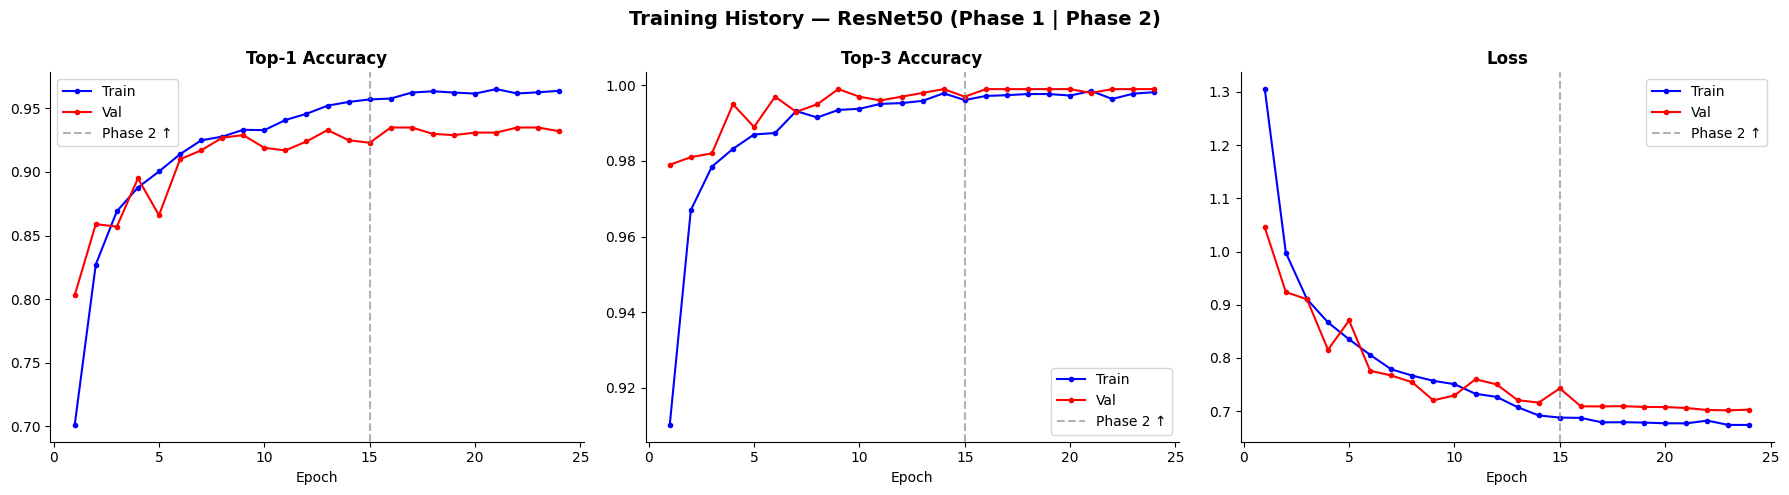

In [40]:
def merge(key):
    return history1.history[key] + history2.history[key]

p1_end = len(history1.history['accuracy'])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Training History — ResNet50 (Phase 1 | Phase 2)',
             fontsize=14, fontweight='bold')

def plot_metric(ax, train_key, val_key, title):
    t = merge(train_key); v = merge(val_key)
    eps = range(1, len(t)+1)
    ax.plot(eps, t, 'b-o', ms=3, label='Train')
    ax.plot(eps, v, 'r-o', ms=3, label='Val')
    ax.axvline(p1_end, color='gray', ls='--', alpha=0.6, label='Phase 2 ↑')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.spines[['top','right']].set_visible(False)

plot_metric(axes[0], 'accuracy',  'val_accuracy',  'Top-1 Accuracy')
plot_metric(axes[1], 'top3_acc',  'val_top3_acc',  'Top-3 Accuracy')
plot_metric(axes[2], 'loss',      'val_loss',       'Loss')

plt.tight_layout()
plt.savefig(WORK_DIR / 'training_history.png', dpi=150, bbox_inches='tight')
plt.show()

## 10 · Evaluation — Multi-class

In [41]:
print("=" * 60)
print("MULTI-CLASS EVALUATION ON VAL SET")
print("=" * 60)

results = model.evaluate(val_ds, verbose=1)

# In newer Keras, model.evaluate() returns [loss, acc, top3_acc, auc]
# positionally — metrics_names may show ['loss', 'compile_metrics'].
# Access by index to avoid KeyError.
loss_val  = results[0]
acc       = results[1]
top3_acc  = results[2]

print(f"\n  Loss         : {loss_val:.4f}")
print(f"  Top-1 Acc    : {acc*100:.2f}%")
print(f"  Top-3 Acc    : {top3_acc*100:.2f}%")
print(f"\nRaw results list: {results}")

# ── Collect all predictions ──
y_true_oh, y_pred_prob = [], []
for images, labels in val_ds:
    probs = model.predict(images, verbose=0)
    y_pred_prob.extend(probs.tolist())
    y_true_oh.extend(labels.numpy().tolist())

y_pred_prob = np.array(y_pred_prob)           # shape (N, 10)
y_true_oh   = np.array(y_true_oh)             # shape (N, 10) one-hot
y_true_int  = np.argmax(y_true_oh, axis=1)    # shape (N,)
y_pred_int  = np.argmax(y_pred_prob, axis=1)  # shape (N,)

short_labels = [
    'Bacterial Spot', 'Early Blight', 'Late Blight', 'Leaf Mold',
    'Septoria', 'Spider Mites', 'Target Spot',
    'Yellow Curl', 'Mosaic Virus', 'Healthy'
]

print("\nClassification Report (multi-class):")
print(classification_report(y_true_int, y_pred_int, target_names=short_labels))

MULTI-CLASS EVALUATION ON VAL SET
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 88ms/step - accuracy: 0.9153 - auc: 0.5737 - loss: 0.7570 - top3_acc: 0.9983

  Loss         : 0.7091
  Top-1 Acc    : 93.50%
  Top-3 Acc    : 99.90%

Raw results list: [0.7091304063796997, 0.9350000023841858, 0.9990000128746033, 0.997482180595398]

Classification Report (multi-class):
                precision    recall  f1-score   support

Bacterial Spot       0.99      0.89      0.94       100
  Early Blight       0.98      0.85      0.91       100
   Late Blight       0.98      0.97      0.97       100
     Leaf Mold       0.99      0.95      0.97       100
      Septoria       0.92      0.99      0.95       100
  Spider Mites       0.81      0.99      0.89       100
   Target Spot       0.92      0.76      0.83       100
   Yellow Curl       0.99      0.95      0.97       100
  Mosaic Virus       0.98      1.00      0.99       100
       Healthy       0.85      1.00      0.92       100

      accuracy                 

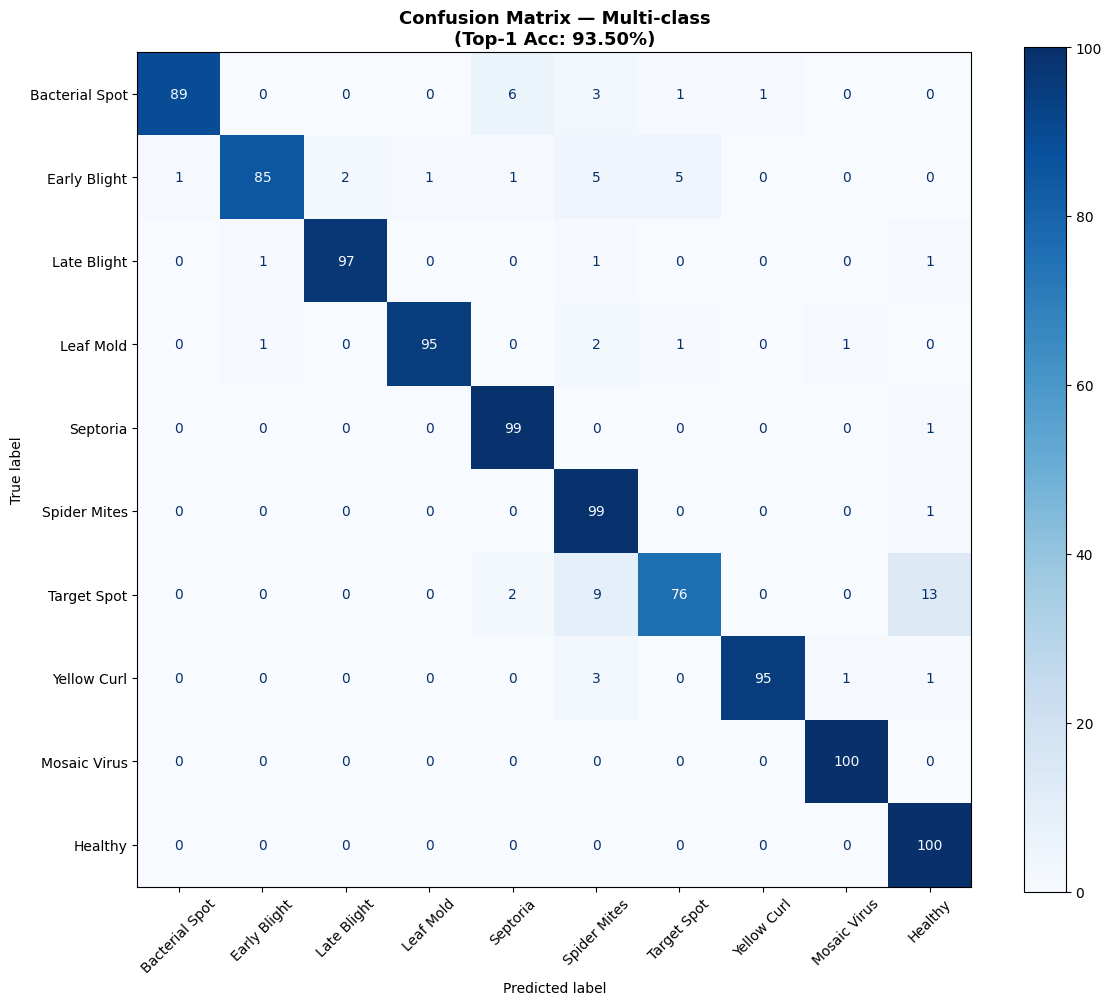

In [42]:
# ── Confusion matrix ──
cm = confusion_matrix(y_true_int, y_pred_int)

fig, ax = plt.subplots(figsize=(12, 10))
disp = ConfusionMatrixDisplay(cm, display_labels=short_labels)
disp.plot(ax=ax, colorbar=True, cmap='Blues', xticks_rotation=45)
ax.set_title(f'Confusion Matrix — Multi-class\n(Top-1 Acc: {acc*100:.2f}%)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(WORK_DIR / 'confusion_matrix_multiclass.png', dpi=150, bbox_inches='tight')
plt.show()

## 11 · Binary Evaluation (Healthy vs Infected)

No retraining needed. We derive the binary result directly from the softmax output:

```
P(infected) = 1 - P(healthy class)
prediction  = "infected" if P(infected) > threshold else "healthy"
```

BINARY EVALUATION (Healthy vs Infected)

  Binary Accuracy : 99.20%
  Threshold used  : 0.5

              precision    recall  f1-score   support

     Healthy       0.93      1.00      0.96       100
    Infected       1.00      0.99      1.00       900

    accuracy                           0.99      1000
   macro avg       0.96      1.00      0.98      1000
weighted avg       0.99      0.99      0.99      1000



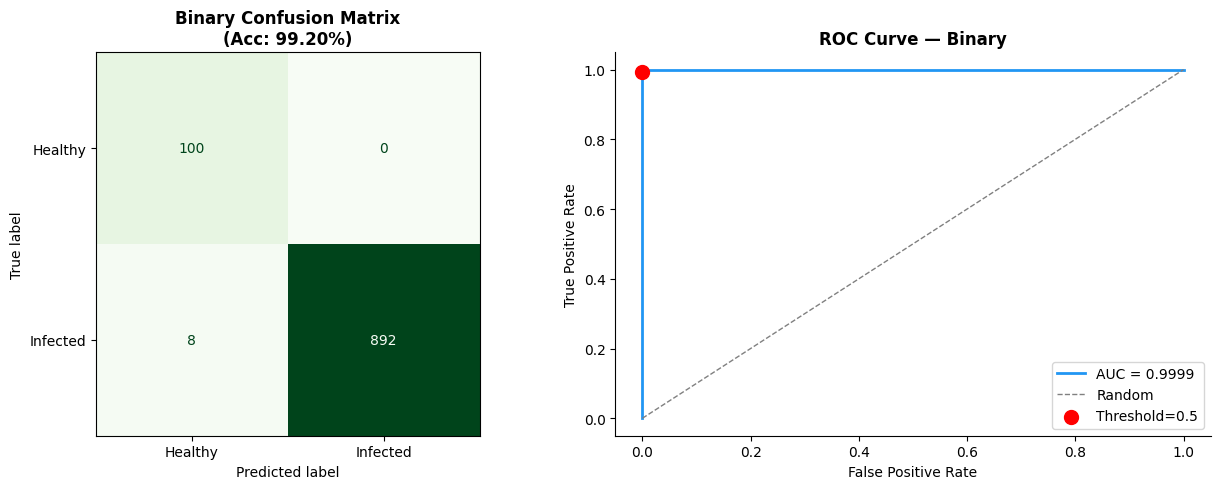


💡 Tip: Raise BINARY_THRESHOLD (e.g. 0.7) to reduce false positives.
        Lower it (e.g. 0.3) to catch more infections (fewer false negatives).


In [43]:
BINARY_THRESHOLD = 0.5   # adjust this to tune sensitivity

# ── Derive binary labels from multi-class predictions ──
p_healthy  = y_pred_prob[:, HEALTHY_IDX]       # P(healthy) for each image
p_infected = 1.0 - p_healthy                   # P(infected)

y_binary_true = (y_true_int != HEALTHY_IDX).astype(int)   # 0=healthy, 1=infected
y_binary_pred = (p_infected >= BINARY_THRESHOLD).astype(int)

binary_acc = np.mean(y_binary_true == y_binary_pred)

print("=" * 60)
print("BINARY EVALUATION (Healthy vs Infected)")
print("=" * 60)
print(f"\n  Binary Accuracy : {binary_acc*100:.2f}%")
print(f"  Threshold used  : {BINARY_THRESHOLD}")
print()
print(classification_report(y_binary_true, y_binary_pred,
                             target_names=['Healthy', 'Infected']))

# ── Binary confusion matrix + ROC curve ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

cm_bin = confusion_matrix(y_binary_true, y_binary_pred)
ConfusionMatrixDisplay(cm_bin, display_labels=['Healthy', 'Infected']).plot(
    ax=ax1, colorbar=False, cmap='Greens'
)
ax1.set_title(f'Binary Confusion Matrix\n(Acc: {binary_acc*100:.2f}%)',
              fontweight='bold')

fpr, tpr, thresholds = roc_curve(y_binary_true, p_infected)
roc_auc_score = auc(fpr, tpr)
ax2.plot(fpr, tpr, color='#2196F3', lw=2,
         label=f'AUC = {roc_auc_score:.4f}')
ax2.plot([0,1],[0,1], color='gray', ls='--', lw=1, label='Random')
# Mark the current threshold
thresh_idx = np.argmin(np.abs(thresholds - BINARY_THRESHOLD))
ax2.scatter(fpr[thresh_idx], tpr[thresh_idx], s=100, color='red', zorder=5,
            label=f'Threshold={BINARY_THRESHOLD}')
ax2.set_xlabel('False Positive Rate'); ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curve — Binary', fontweight='bold')
ax2.legend()
ax2.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(WORK_DIR / 'binary_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n💡 Tip: Raise BINARY_THRESHOLD (e.g. 0.7) to reduce false positives.")
print("        Lower it (e.g. 0.3) to catch more infections (fewer false negatives).")

## 12 · Sample Predictions (Both Modes)

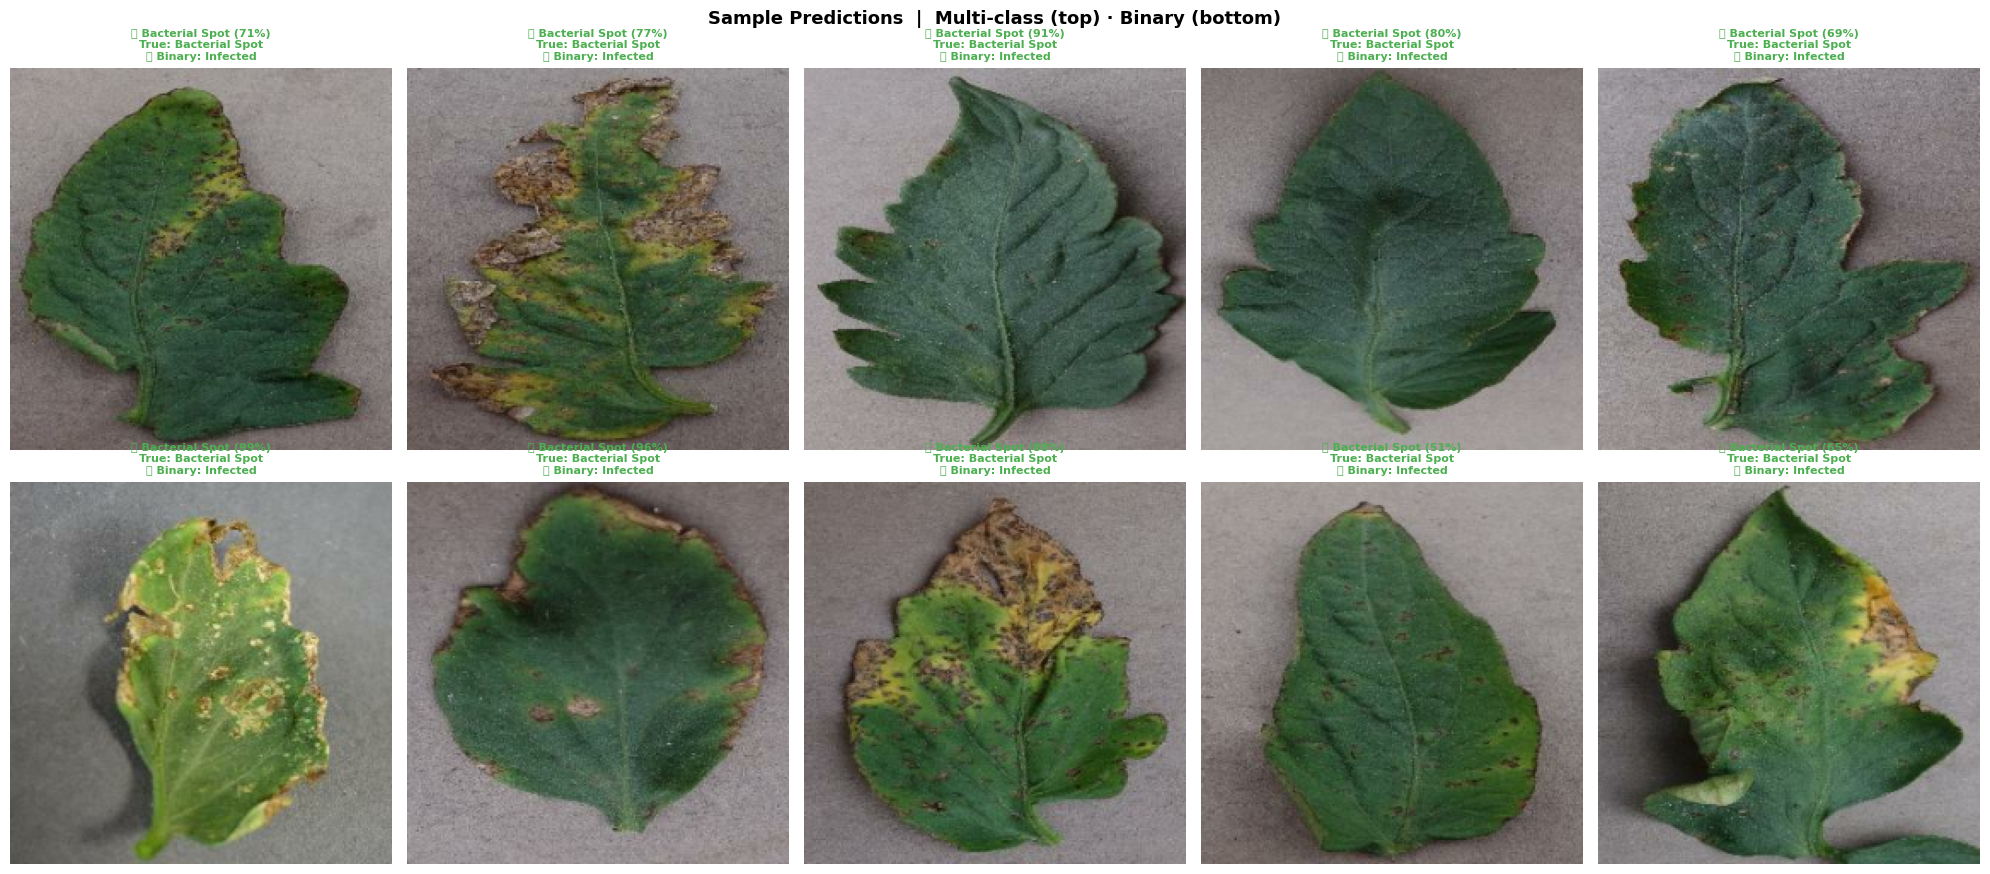

In [44]:
# ── Collect a batch of val images ──
val_images_list, val_labels_list = [], []
for imgs, lbls in val_ds:
    val_images_list.extend(imgs.numpy().astype(np.float32))
    val_labels_list.extend(np.argmax(lbls.numpy(), axis=1).tolist())
    if len(val_images_list) >= 64:
        break

# ── Plot 10 random samples showing both multi-class & binary output ──
sample_idx = random.sample(range(len(val_images_list)), 10)

fig, axes = plt.subplots(2, 5, figsize=(20, 9))
fig.suptitle('Sample Predictions  |  Multi-class (top) · Binary (bottom)',
             fontsize=13, fontweight='bold')

for ax, idx in zip(axes.flatten(), sample_idx):
    img   = val_images_list[idx]
    true  = val_labels_list[idx]
    probs = model.predict(img[np.newaxis], verbose=0)[0]   # shape (10,)

    # Multi-class
    pred_cls  = int(np.argmax(probs))
    pred_conf = float(probs[pred_cls])
    mc_correct = (pred_cls == true)

    # Binary
    p_inf = float(1.0 - probs[HEALTHY_IDX])
    bin_pred = 'Infected' if p_inf >= BINARY_THRESHOLD else 'Healthy'
    bin_true = 'Healthy' if true == HEALTHY_IDX else 'Infected'
    bin_correct = (bin_pred == bin_true)

    ax.imshow(np.clip(img.astype(np.float32), 0, 1))
    ax.axis('off')

    mc_emoji  = '✅' if mc_correct  else '❌'
    bin_emoji = '✅' if bin_correct else '❌'
    pred_name = short_labels[pred_cls]
    true_name = short_labels[true]

    title = (
        f"{mc_emoji} {pred_name} ({pred_conf*100:.0f}%)\n"
        f"True: {true_name}\n"
        f"{bin_emoji} Binary: {bin_pred}"
    )
    ax.set_title(title, fontsize=8,
                 color='#4CAF50' if mc_correct else '#F44336',
                 fontweight='bold')

plt.tight_layout()
plt.savefig(WORK_DIR / 'sample_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

## 13 · Save Model

In [45]:
keras_path = MODEL_DIR / 'tomato_disease_resnet50.keras'
h5_path    = MODEL_DIR / 'tomato_disease_resnet50.h5'

model.save(str(keras_path))
model.save(str(h5_path), save_format='h5')  # explicit HDF5 export

print(f"Saved:")
print(f"  {keras_path}  ({keras_path.stat().st_size/1024**2:.1f} MB)")
print(f"  {h5_path}     ({h5_path.stat().st_size/1024**2:.1f} MB)")

# Save class names and healthy index so the server can reload them
import json
meta = {
    'class_names':    CLASS_NAMES,
    'healthy_idx':    HEALTHY_IDX,
    'disease_indices': DISEASE_INDICES,
    'binary_threshold': BINARY_THRESHOLD,
    'img_size':       list(IMG_SIZE),
}
meta_path = MODEL_DIR / 'model_meta.json'
with open(meta_path, 'w') as f:
    json.dump(meta, f, indent=2)
print(f"  {meta_path}")

print("\n📥 Download from: Kaggle → Output tab → /kaggle/working/models/")
print("\nAll output files:")
for f in sorted(WORK_DIR.rglob('*')):
    if f.is_file():
        print(f"  {str(f.relative_to(WORK_DIR)):<50} {f.stat().st_size/1024:>8.0f} KB")

Saved:
  /kaggle/working/models/tomato_disease_resnet50.keras  (113.3 MB)
  /kaggle/working/models/tomato_disease_resnet50.h5     (104.0 MB)
  /kaggle/working/models/model_meta.json

📥 Download from: Kaggle → Output tab → /kaggle/working/models/

All output files:
  .virtual_documents/__notebook_source__.ipynb             26 KB
  augmentation_examples.png                              2334 KB
  binary_evaluation.png                                    76 KB
  confusion_matrix_multiclass.png                         124 KB
  dataset_distribution.png                                 51 KB
  models/final_best.keras                              116031 KB
  models/model_meta.json                                    1 KB
  models/phase1_best.keras                             116031 KB
  models/tomato_disease_resnet50.h5                    106484 KB
  models/tomato_disease_resnet50.keras                 116031 KB
  sample_images.png                                      3638 KB
  sample_predictions

## 14 · Quick Inference Function

Copy this function into `3_server.py` to use the trained model on ESP32-CAM images.

Model reloaded from disk ✅


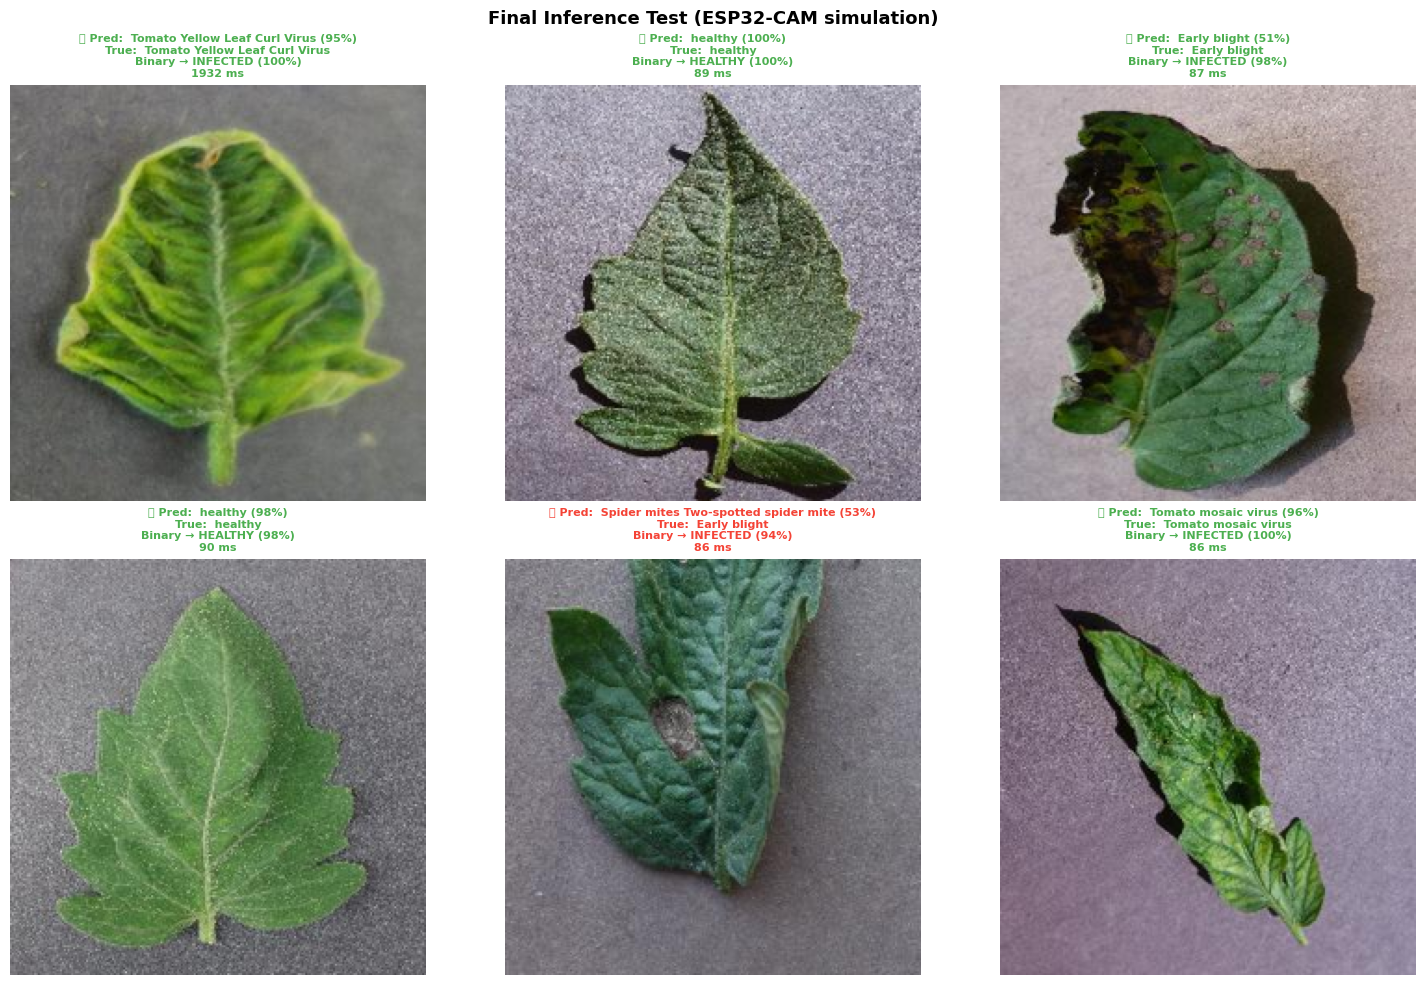


✅ All done! Download your model from the Output tab.


In [46]:
import time

# Reload from disk to validate saved file
loaded_model = tf.keras.models.load_model(
    str(keras_path),
    custom_objects={'TFImageAugmentation': TFImageAugmentation}
)
print("Model reloaded from disk ✅")

def predict_leaf(img_path: str,
                 model,
                 class_names: list,
                 healthy_idx: int,
                 binary_threshold: float = 0.5) -> dict:
    """
    Full prediction pipeline — mirrors 3_server.py preprocessing.
    Simulates ESP32-CAM capture: resize to 640×360 first, then 224×224.

    Returns:
        {
          'disease':        str,    # e.g. 'Tomato__Early_blight'
          'disease_conf':   float,  # 0–1
          'all_probs':      dict,   # {class_name: probability}
          'binary':         str,    # 'healthy' or 'infected'
          'binary_conf':    float,  # 0–1
          'inference_ms':   float,
        }
    """
    img = Image.open(img_path).convert('RGB')
    img = img.resize((640, 360), Image.LANCZOS)   # simulate ESP32 capture
    img = img.resize(IMG_SIZE, Image.LANCZOS)      # model input size
    arr = np.array(img, dtype=np.float32) / 255.0
    arr = arr[np.newaxis, ...]                     # add batch dim

    t0    = time.perf_counter()
    probs = model.predict(arr, verbose=0)[0]       # shape (10,)
    ms    = (time.perf_counter() - t0) * 1000

    pred_cls  = int(np.argmax(probs))
    pred_conf = float(probs[pred_cls])
    p_infected = float(1.0 - probs[healthy_idx])

    return {
        'disease':       class_names[pred_cls],
        'disease_conf':  round(pred_conf, 4),
        'all_probs':     {n: round(float(p), 4)
                          for n, p in zip(class_names, probs)},
        'binary':        'infected' if p_infected >= binary_threshold else 'healthy',
        'binary_conf':   round(p_infected if p_infected >= binary_threshold
                               else 1 - p_infected, 4),
        'inference_ms':  round(ms, 1),
    }


# ── Test on 6 val images ──
test_imgs = random.sample(
    list(VAL_DIR.rglob('*.*')), 6
)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Final Inference Test (ESP32-CAM simulation)',
             fontsize=13, fontweight='bold')

for ax, img_path in zip(axes.flatten(), test_imgs):
    true_cls = img_path.parent.name
    result   = predict_leaf(str(img_path), loaded_model,
                             CLASS_NAMES, HEALTHY_IDX, BINARY_THRESHOLD)

    mc_correct = (result['disease'] == true_cls)
    color = '#4CAF50' if mc_correct else '#F44336'

    ax.imshow(Image.open(img_path).convert('RGB').resize(IMG_SIZE))
    ax.axis('off')

    pred_short  = result['disease'].replace('Tomato__', '').replace('_', ' ')
    true_short  = true_cls.replace('Tomato__', '').replace('_', ' ')
    emoji = '✅' if mc_correct else '❌'

    ax.set_title(
        f"{emoji} Pred: {pred_short} ({result['disease_conf']*100:.0f}%)\n"
        f"True: {true_short}\n"
        f"Binary → {result['binary'].upper()} ({result['binary_conf']*100:.0f}%)\n"
        f"{result['inference_ms']:.0f} ms",
        fontsize=8, color=color, fontweight='bold'
    )

plt.tight_layout()
plt.savefig(WORK_DIR / 'final_inference_test.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ All done! Download your model from the Output tab.")